## Model Training
---

In [12]:
# importing the required libraries library 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# reading the dataset csv file that will required for model training
df = pd.read_csv('..\\datasets\\student_cleaned.csv')

df.head()

,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,15,0,12,1.0,65,2,0,0,40,39,72,81,50.33,1,1
1,19,1,9,1.6,58,1,0,1,80,44,35,47,53.00,1,1
2,14,1,12,3.6,64,0,1,1,83,73,59,58,71.67,2,1
3,18,1,9,5.5,68,2,1,0,68,48,77,54,64.33,1,1
4,14,0,10,5.0,80,0,1,0,41,46,36,68,41.00,0,0


In [13]:
from sklearn.model_selection import train_test_split

# Define X by dropping target columns and redundant features
X = df.drop(columns=['Performance_Level',"Final_Percentage",'Pass_Fail'])
y = df['Pass_Fail']

# Split the data (80% for training and 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# display the shape of training and testing data
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (4000, 12)
Testing features shape: (1000, 12)


In [14]:
from sklearn.tree import DecisionTreeClassifier

# initialize the model
model = DecisionTreeClassifier()

# train the model using the training data
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Confusion Matrix:
[[ 48  12]
 [  9 931]]


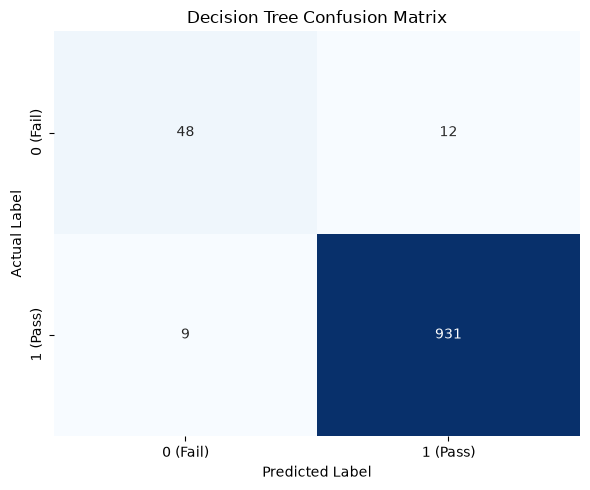

In [15]:
from sklearn.metrics import confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Prediction probabilities (Optional - useful for ROC Curve)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['0 (Fail)', '1 (Pass)'],
    yticklabels=['0 (Fail)', '1 (Pass)']
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

print("\nClassification Report: ")
print(classification_report(y_test, y_pred))

print("Performance Summary: ")
print(f"Overall Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:         {roc_auc_score(y_test, y_pred_proba):.4f}")


Classification Report: 
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        60
           1       0.99      0.99      0.99       940

    accuracy                           0.98      1000
   macro avg       0.91      0.90      0.90      1000
weighted avg       0.98      0.98      0.98      1000

Performance Summary: 
Overall Test Accuracy: 0.9790
ROC-AUC Score:         0.8952


                       Feature  Importance
10               English_Score    0.357855
9                Science_Score    0.326708
8                   Math_Score    0.248117
11         Previous_Year_Score    0.015822
0                          Age    0.015249
4        Attendance_Percentage    0.014336
2                        Class    0.011997
5           Parental_Education    0.003917
3          Study_Hours_Per_Day    0.003428
1                       Gender    0.002571
6              Internet_Access    0.000000
7   Extracurricular_Activities    0.000000


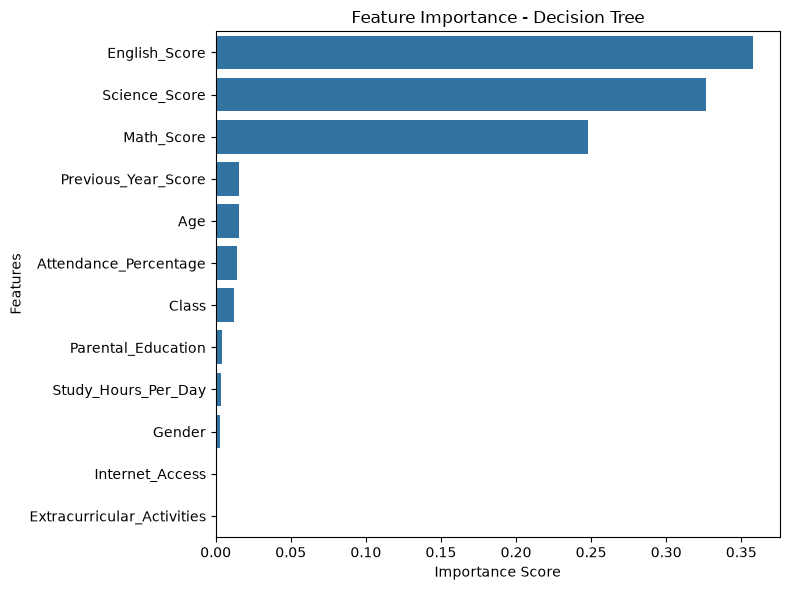

In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(8,6))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()